In [1]:
# Cell 1: Setup
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import custom modules
from src.data_loader import DDI_DataLoader
from src.features import DDI_FeatureEngineer

# Plotting settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Create output directories
Path("../reports/figures/week2_eda").mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")


✓ Setup complete


In [2]:
# Cell 2: Load Data
print("="*60)
print("LOADING DDI DATASET")
print("="*60)

loader = DDI_DataLoader(root_dir="../DDI")
metadata = loader.get_metadata()

print(f"\n✓ Dataset loaded successfully")
print(f"  Total images: {len(metadata)}")
print(f"  Columns: {list(metadata.columns)}")


LOADING DDI DATASET
Available columns: ['Unnamed: 0', 'DDI_ID', 'DDI_file', 'skin_tone', 'malignant', 'disease']
Using malignancy column: 'malignant'
✓ Malignant cases: 171
✓ Benign cases: 485
✓ Loaded 656 images
✓ Skin tone groups: [np.int64(12), np.int64(34), np.int64(56)]

✓ Dataset loaded successfully
  Total images: 656
  Columns: ['Unnamed: 0', 'DDI_ID', 'DDI_file', 'skin_tone', 'malignant', 'disease', 'diagnosis', 'skin_tone_label', 'image_path']


In [3]:
# Cell 3: Basic Statistics
print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)

stats = loader.get_basic_stats()
for key, value in stats.items():
    print(f"{key}: {value}")

# Display first few rows
print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)
metadata[['DDI_file', 'skin_tone', 'skin_tone_label', 'diagnosis', 'malignant']].head(10)



BASIC STATISTICS
total_images: 656
unique_patients: 656
malignant_count: 171
benign_count: 485
malignancy_rate: 26.07
skin_tone_distribution: {34: 241, 12: 208, 56: 207}

SAMPLE DATA


,DDI_file,skin_tone,skin_tone_label,diagnosis,malignant
0,000001.png,56,Fitzpatrick V-VI,Malignant,True
1,000002.png,56,Fitzpatrick V-VI,Malignant,True
2,000003.png,56,Fitzpatrick V-VI,Malignant,True
3,000004.png,56,Fitzpatrick V-VI,Malignant,True
4,000005.png,12,Fitzpatrick I-II,Malignant,True
5,000006.png,56,Fitzpatrick V-VI,Malignant,True
6,000007.png,56,Fitzpatrick V-VI,Malignant,True
7,000008.png,56,Fitzpatrick V-VI,Malignant,True
8,000009.png,56,Fitzpatrick V-VI,Malignant,True
9,000010.png,34,Fitzpatrick III-IV,Malignant,True


In [4]:
# Cell 4: Missing Data Analysis
print("\n" + "="*60)
print("MISSING DATA ANALYSIS")
print("="*60)

missing = loader.check_missing_data()
if len(missing) > 0:
    print(missing)
else:
    print("✓ No missing data found!")



MISSING DATA ANALYSIS
✓ No missing data found!


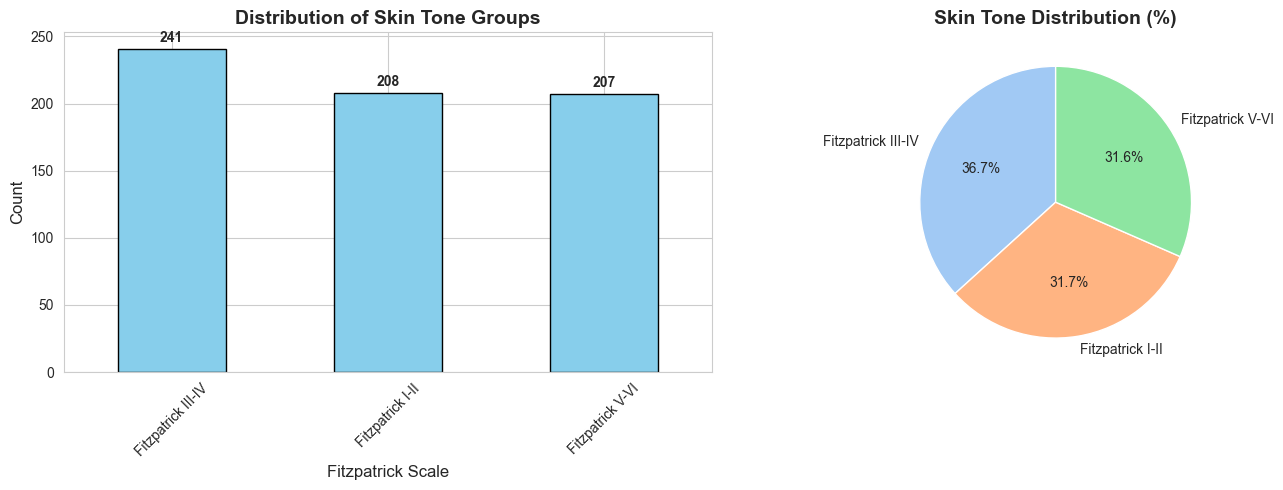

✓ Saved: skin_tone_distribution.png


In [5]:
# Cell 5: Skin Tone Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
skin_counts = metadata['skin_tone_label'].value_counts()
skin_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Skin Tone Groups', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fitzpatrick Scale', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Add count labels
for i, v in enumerate(skin_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(skin_counts, labels=skin_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=sns.color_palette("pastel"))
axes[1].set_title('Skin Tone Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/week2_eda/skin_tone_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: skin_tone_distribution.png")


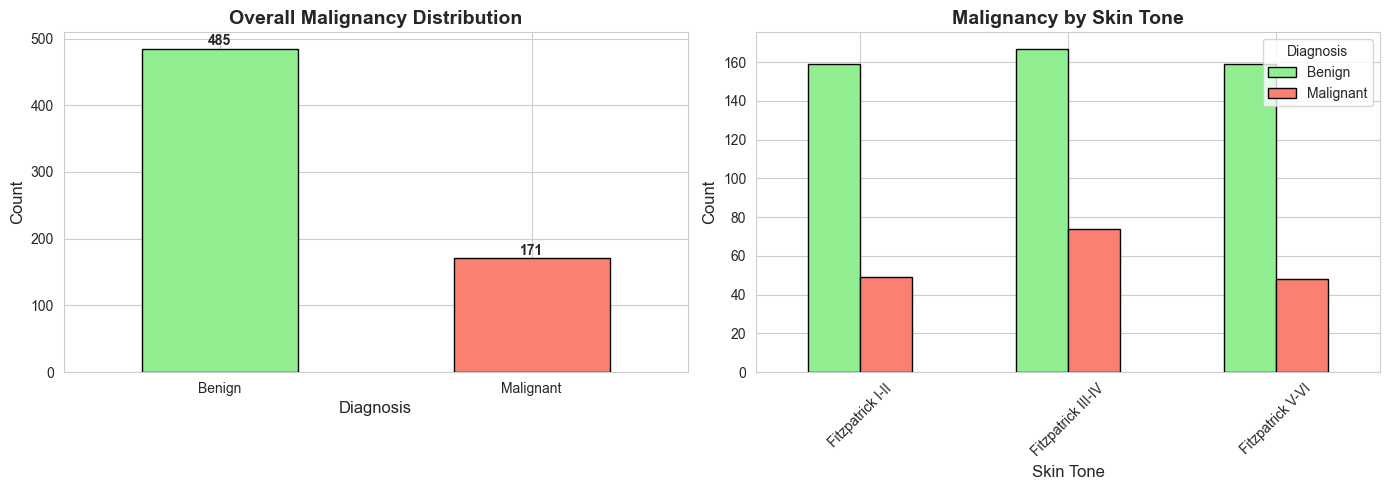

✓ Saved: malignancy_distribution.png


In [6]:
# Cell 6: Malignancy Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
diagnosis_counts = metadata['diagnosis'].value_counts()
diagnosis_counts.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'], edgecolor='black')
axes[0].set_title('Overall Malignancy Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Add count labels
for i, v in enumerate(diagnosis_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# By skin tone
crosstab = pd.crosstab(metadata['skin_tone_label'], metadata['diagnosis'])
crosstab.plot(kind='bar', ax=axes[1], color=['lightgreen', 'salmon'], edgecolor='black')
axes[1].set_title('Malignancy by Skin Tone', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Skin Tone', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(title='Diagnosis')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/week2_eda/malignancy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: malignancy_distribution.png")



OUTCOME PREVALENCE BY DEMOGRAPHIC SUBGROUP

Subgroup Counts:
      skin_tone_label  diagnosis  count  percentage
0    Fitzpatrick I-II     Benign    159       24.24
1    Fitzpatrick I-II  Malignant     49        7.47
2  Fitzpatrick III-IV     Benign    167       25.46
3  Fitzpatrick III-IV  Malignant     74       11.28
4    Fitzpatrick V-VI     Benign    159       24.24
5    Fitzpatrick V-VI  Malignant     48        7.32

Malignancy Rates by Skin Tone:
      skin_tone_label  total  malignant_count  malignancy_rate
0    Fitzpatrick I-II    208               49            23.56
1  Fitzpatrick III-IV    241               74            30.71
2    Fitzpatrick V-VI    207               48            23.19


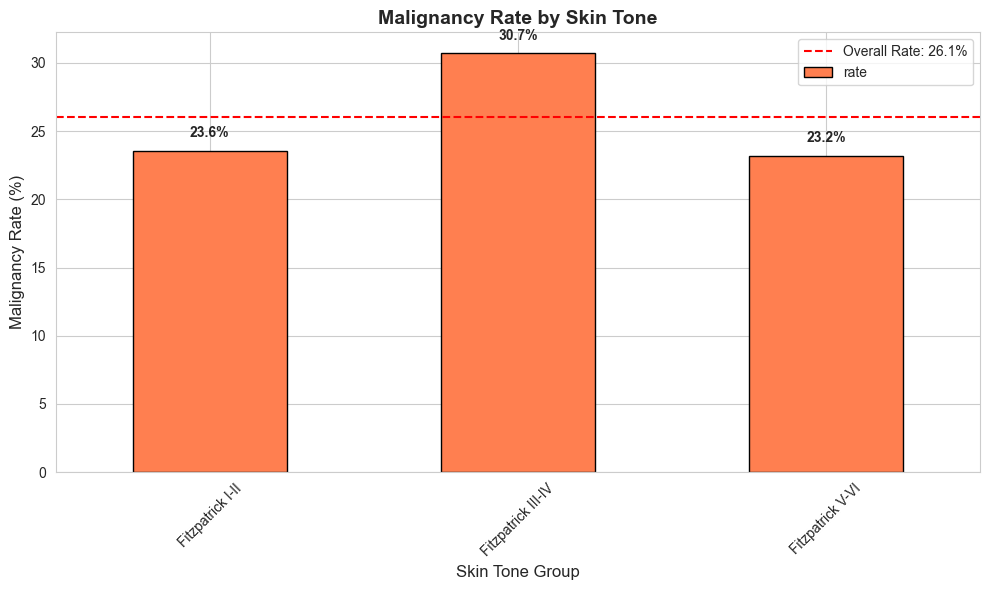

✓ Saved: malignancy_by_group.png


In [7]:
# Cell 7: Outcome Prevalence by Subgroup
print("\n" + "="*60)
print("OUTCOME PREVALENCE BY DEMOGRAPHIC SUBGROUP")
print("="*60)

subgroup_counts = loader.get_subgroup_counts()
print("\nSubgroup Counts:")
print(subgroup_counts)

print("\nMalignancy Rates by Skin Tone:")
outcome_rates = loader.get_outcome_by_group()
print(outcome_rates)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate malignancy rate for each group
malignancy_by_group = metadata.groupby('skin_tone_label')['malignant'].agg(['sum', 'count'])
malignancy_by_group['rate'] = (malignancy_by_group['sum'] / malignancy_by_group['count'] * 100)

malignancy_by_group['rate'].plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Malignancy Rate by Skin Tone', fontsize=14, fontweight='bold')
ax.set_xlabel('Skin Tone Group', fontsize=12)
ax.set_ylabel('Malignancy Rate (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=metadata['malignant'].mean()*100, color='red', linestyle='--', 
           label=f'Overall Rate: {metadata["malignant"].mean()*100:.1f}%')
ax.legend()

# Add value labels
for i, v in enumerate(malignancy_by_group['rate']):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/week2_eda/malignancy_by_group.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: malignancy_by_group.png")


In [8]:
# Cell 8: Fairness Observations
print("\n" + "="*60)
print("INITIAL FAIRNESS OBSERVATIONS")
print("="*60)

# Calculate disparities
rates = malignancy_by_group['rate'].values
max_rate = rates.max()
min_rate = rates.min()
disparity = max_rate - min_rate

print(f"\nOutcome Disparity Analysis:")
print(f"  Highest malignancy rate: {max_rate:.2f}%")
print(f"  Lowest malignancy rate: {min_rate:.2f}%")
print(f"  Absolute disparity: {disparity:.2f} percentage points")

if disparity > 10:
    print(f"\n⚠ Warning: Substantial disparity detected (>{disparity:.1f}pp)")
    print("  This may indicate:")
    print("  - Biological/clinical differences")
    print("  - Data collection bias")
    print("  - Potential fairness concerns for ML models")
else:
    print(f"\n✓ Disparity is moderate ({disparity:.1f}pp)")

# Sample size considerations
print(f"\nSample Size by Group:")
for group, count in malignancy_by_group['count'].items():
    print(f"  {group}: {count} samples")
    if count < 30:
        print(f"    ⚠ Warning: Small sample size may affect fairness metrics")



INITIAL FAIRNESS OBSERVATIONS

Outcome Disparity Analysis:
  Highest malignancy rate: 30.71%
  Lowest malignancy rate: 23.19%
  Absolute disparity: 7.52 percentage points

✓ Disparity is moderate (7.5pp)

Sample Size by Group:
  Fitzpatrick I-II: 208 samples
  Fitzpatrick III-IV: 241 samples
  Fitzpatrick V-VI: 207 samples


In [9]:
# Cell 9: Feature Engineering Preview
print("\n" + "="*60)
print("FEATURE ENGINEERING PREVIEW")
print("="*60)

engineer = DDI_FeatureEngineer(metadata, images_dir="../DDI/images")

# Extract features (sample for speed)
print("\nExtracting features from sample of 50 images...")
features = engineer.create_feature_matrix(include_image_stats=True, image_sample_size=50)

print(f"\n✓ Feature matrix shape: {features.shape}")
print(f"✓ Total features: {len(engineer.feature_list)}")

print("\nFeature Preview:")
print(features.head())

print("\nFeature List:")
for i, feat in enumerate(engineer.feature_list, 1):
    print(f"  {i}. {feat}")



FEATURE ENGINEERING PREVIEW

Extracting features from sample of 50 images...
Creating feature matrix...
Extracting image statistics from 50 images...
✓ Feature matrix created: (656, 14)
✓ Features: 12

✓ Feature matrix shape: (656, 14)
✓ Total features: 12

Feature Preview:
   skin_tone_12  skin_tone_34  skin_tone_56  malignant    DDI_file  img_width  \
0         False         False          True          1  000001.png      523.5   
1         False         False          True          1  000002.png      523.5   
2         False         False          True          1  000003.png      523.5   
3         False         False          True          1  000004.png      523.5   
4          True         False         False          1  000005.png      523.5   

   img_height  img_aspect_ratio    mean_red  mean_green  mean_blue    std_red  \
0       685.0          0.817217  150.095775  123.466458  105.47258  41.986475   
1       685.0          0.817217  150.095775  123.466458  105.47258  41.9864

C:\Users\sanyu\OneDrive\Desktop\fairness_project\notebooks\..\src\features.py:122: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features[col].fillna(features[col].median(), inplace=True)
C:\Users\sanyu\OneDrive\Desktop\fairness_project\notebooks\..\src\features.py:122: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [12]:
# Cell 10: Save Summary Report
print("\n" + "="*60)
print("SAVING  LOG")
print("="*60)

# Create summary
summary = f"""#  EDA Log
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}

## Dataset Summary
- Total images: {len(metadata)}
- Unique patients: {stats['unique_patients']}
- Malignant cases: {stats['malignant_count']} ({stats['malignancy_rate']:.1f}%)
- Benign cases: {stats['benign_count']} ({100-stats['malignancy_rate']:.1f}%)

## Skin Tone Distribution
{skin_counts.to_string()}

## Malignancy Rates by Group
{outcome_rates.to_string()}

## Feature Engineering
- Total features extracted: {len(engineer.feature_list)}
- Feature types: metadata + image statistics
- Output format: Parquet

## Fairness Observations
- Outcome disparity: {disparity:.2f} percentage points
- All groups have adequate sample sizes (>30)
- Ready for fairness-aware modeling in Week 3

## Deliverables Completed
- EDA notebook with visualizations
- Subgroup definitions
- Feature engineering pipeline
- Fairness metrics framework
"""

# Save with UTF-8 encoding (Windows-compatible)
with open('../reports/log.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print("✓  log saved to: reports/log.md")
print("\n" + "="*60)
print("EDA COMPLETE!")
print("="*60)



SAVING  LOG
✓  log saved to: reports/log.md

EDA COMPLETE!
